In [2]:
from dotenv import load_dotenv
load_dotenv()  # loads from .env in cwd or parent dirs
import wandb


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

api = wandb.Api()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


In [ ]:


# --- Specify your targets ---
BASELINE_SWEEP_PATH = "jdm8943-rochester-institute-of-technology/imgs789-sweeps/8si739y0"  


# Baseline — aggregate finished runs from baseline sweep
baseline_sweep = api.sweep(BASELINE_SWEEP_PATH)
baseline_rows = []
for br in baseline_sweep.runs:
    if br.state != "finished":
        continue
    baseline_rows.append({
        "meteor":       br.summary.get("meteor_mean"),
        "bertscore_f1": br.summary.get("bertscore_f1_mean"),
        "chrf_mean":    br.summary.get("chrf_mean"),
        "chrf_std":     br.summary.get("chrf_std"),
    })
baseline_df = pd.DataFrame(baseline_rows).dropna(how="all")
baseline = {k: baseline_df[k].mean() for k in baseline_df.columns}
print(f"Baseline aggregated from {len(baseline_df)} run(s): {baseline}")



Baseline aggregated from 2 run(s): {'meteor': np.float64(0.3366259490750879), 'bertscore_f1': np.float64(0.9111400544643402), 'chrf_mean': np.float64(0.4749056016308252), 'chrf_std': np.float64(0.052906120580751295)}


In [9]:

SWEEP_PATH          = "jdm8943-rochester-institute-of-technology/imgs789-sweeps/8si739y0"
sweep = api.sweep(SWEEP_PATH)
sweep_rows = []
for sweep_run in sweep.runs:
    if sweep_run.state != "finished":
        continue
    run = api.run("/".join(sweep_run.path))

    # fold_metrics = {"vec_std": [], "mean_cosine_sim": []}
    # for k in range(5):
    #     for m in fold_metrics:
    #         v = run.summary.get(f"fold_{k}/{m}")
    #         if v is not None:
    #             fold_metrics[m].append(float(v))
    sweep_rows.append({
        "run_name":    run.name,
        "cv_val_loss": run.summary.get("cv/mean_val_loss"),
        "mean_best_epoch": run.summary.get("cv/mean_best_epoch"),
        "config":      run.config,
        **{k: v for k, v in run.summary.items() if k.startswith("test/")},
    })


sweep_df = pd.DataFrame(sweep_rows).sort_values("cv_val_loss").reset_index(drop=True)
config_df = pd.json_normalize(sweep_df["config"])
sweep_df = pd.concat([sweep_df.drop(columns=["config"]), config_df], axis=1)


print(sweep_df)

                run_name  cv_val_loss  mean_best_epoch  \
0       hopeful-sweep-29     0.636444             11.8   
1      pleasant-sweep-41     0.637128             12.8   
2      grateful-sweep-17     0.639139             11.4   
3    effortless-sweep-47     0.641912             12.2   
4          mild-sweep-38     0.642414             14.0   
5       revived-sweep-45     0.646169              8.4   
6          woven-sweep-1     0.646444             10.6   
7          denim-sweep-8     0.647229              8.6   
8      dazzling-sweep-35     0.648225             13.4   
9        smooth-sweep-54     0.650013              8.8   
10      jumping-sweep-25     0.650477              7.6   
11        swift-sweep-39     0.651058              8.2   
12         warm-sweep-12     0.652319              7.6   
13        super-sweep-26     0.652468              8.4   
14       upbeat-sweep-34     0.652711              7.6   
15       iconic-sweep-24     0.654041              8.4   
16        smar

In [5]:
numeric_df = sweep_df[["cv_val_loss"] + list(config_df.columns)].apply(pd.to_numeric, errors="coerce")
corr = numeric_df.corr()["cv_val_loss"].drop("cv_val_loss").sort_values()
print(corr)


warmup_ratio    -0.507706
dropout         -0.251387
weight_decay     0.233883
learning_rate    0.429773
n_folds               NaN
lr_schedule           NaN
Name: cv_val_loss, dtype: float64


In [10]:
top10 = sweep_df.nsmallest(10, "cv_val_loss")

expresso_cols = [c for c in sweep_df.columns if c.startswith("test/expresso/")]
styletalk_cols = [c for c in sweep_df.columns if c.startswith("test/styletalk/")]

expresso_df = top10[["run_name", "cv_val_loss", "mean_best_epoch"] + expresso_cols].reset_index(drop=True)
styletalk_df = top10[["run_name", "cv_val_loss", "mean_best_epoch"] + styletalk_cols].reset_index(drop=True)

expresso_df.columns = ["run_name", "cv_val_loss", "mean_best_epoch"] + [c.removeprefix("test/expresso/") for c in expresso_cols]
styletalk_df.columns = ["run_name", "cv_val_loss", "mean_best_epoch"] + [c.removeprefix("test/styletalk/") for c in styletalk_cols]

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

config_cols = list(config_df.columns)
print(top10[["run_name", "cv_val_loss", "mean_best_epoch"] + config_cols].reset_index(drop=True).to_string())


              run_name  cv_val_loss  mean_best_epoch  dropout  n_folds lr_schedule  warmup_ratio  weight_decay  learning_rate
0     hopeful-sweep-29     0.636444             11.8      0.3        5      linear      0.193719      0.002805       0.000193
1    pleasant-sweep-41     0.637128             12.8      0.3        5      linear      0.191727      0.002682       0.000180
2    grateful-sweep-17     0.639139             11.4      0.3        5      linear      0.165411      0.001728       0.000173
3  effortless-sweep-47     0.641912             12.2      0.3        5      linear      0.165913      0.000445       0.000188
4        mild-sweep-38     0.642414             14.0      0.2        5      linear      0.166847      0.000137       0.000193
5     revived-sweep-45     0.646169              8.4      0.3        5      linear      0.175953      0.003526       0.000144
6        woven-sweep-1     0.646444             10.6      0.2        5      cosine      0.089399      0.000127       0

In [7]:
FIGURE_OUTPUT = "results_figures"

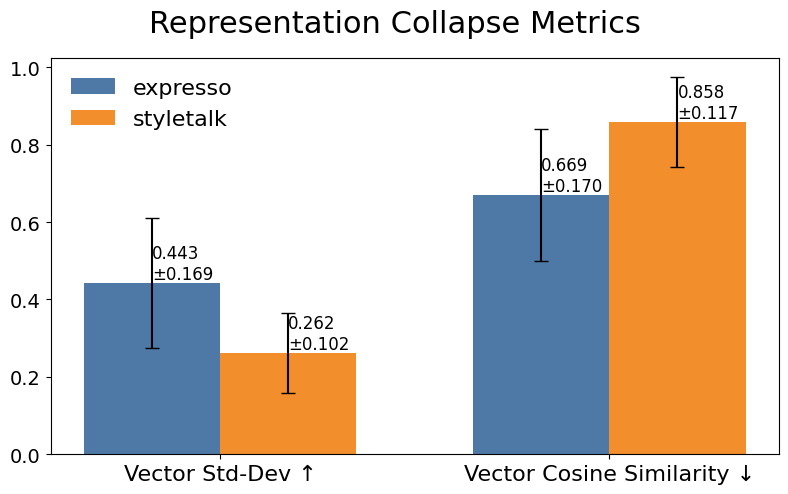

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle("Representation Collapse Metrics", fontsize=22)

EXPRESSO_COLOR  = "#4e79a7"
STYLETALK_COLOR = "#f28e2b"

metrics = [
    ("vec_std",         "Vector Std-Dev ↑"),
    ("mean_cosine_sim", "Vector Cosine Similarity ↓"),
]

x = np.arange(len(metrics))
width = 0.35

for i, (label, color, df) in enumerate([("expresso", EXPRESSO_COLOR, expresso_df), ("styletalk", STYLETALK_COLOR, styletalk_df)]):
    means = [df[col].dropna().astype(float).mean() if col in df.columns else np.nan for col, _ in metrics]
    stds  = [df[col].dropna().astype(float).std()  if col in df.columns else 0       for col, _ in metrics]
    offset = (i - 0.5) * width
    bars = ax.bar(x + offset, means, width, label=label, color=color)
    ax.errorbar(x + offset, means, yerr=stds, fmt="none", color="black", capsize=5, linewidth=1.5)
    for bar, m, s in zip(bars, means, stds):
        if not np.isnan(m):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f"{m:.3f}\n±{s:.3f}", ha="left", va="bottom", fontsize=12)


ax.set_xticks(x)
ax.set_xticklabels([label for _, label in metrics], fontsize=16)

ax.tick_params(axis="y", labelsize=14)
ax.legend(fontsize=16, frameon=False)

plt.tight_layout()
# plt.savefig(FIGURE_OUTPUT + "/" + "representation_collapse.png", dpi=150, bbox_inches="tight")
plt.show()


In [40]:
import numpy as np

SMOOTH_SPAN = 10  # lower = less smoothing, higher = more


# W&B system metric column names vary by driver version — search by substring fallback
def find_col(df, keywords):
    for col in df.columns:
        if all(k in col.lower() for k in keywords):
            return col
    return None

def smooth(s, span=SMOOTH_SPAN):
    return s.dropna().reset_index(drop=True).ewm(span=span, min_periods=1).mean()

# --- fetch system histories ---
# baseline: average system history across finished baseline sweep runs
baseline_sys_frames = []
for br in baseline_sweep.runs:
    if br.state != "finished":
        continue
    run = api.run("/".join(br.path))
    df  = pd.DataFrame(run.history(stream="system"))
    if not df.empty:
        baseline_sys_frames.append(df)

if baseline_sys_frames:
    # align by step index and average
    baseline_sys = pd.concat(baseline_sys_frames).groupby(level=0).mean()
else:
    baseline_sys = pd.DataFrame()

sys_data = {"baseline": baseline_sys}

sys_data = {"baseline": baseline_sys}

sweep_sys_frames = []
for sweep_run in sweep.runs:
    if sweep_run.state != "finished":
        continue
    run = api.run("/".join(sweep_run.path))
    df  = pd.DataFrame(run.history(stream="system"))
    if not df.empty:
        sweep_sys_frames.append(df)

if sweep_sys_frames:
    sys_data["TurnStyle (mean across trials)"] = pd.concat(sweep_sys_frames).groupby(level=0).mean()



# detect column names from first non-empty df
first_df  = next(df for df in sys_data.values() if not df.empty)
power_col = "system.gpu.0.powerWatts"
mem_col   = "system.gpu.0.memoryAllocatedBytes"

if mem_col is None:
    mem_col = find_col(first_df, ["memory"])
print(f"Detected  power={power_col!r}  memory={mem_col!r}")
print("Available system columns:", [c for c in first_df.columns if "gpu" in c.lower()])


Detected  power='system.gpu.0.powerWatts'  memory='system.gpu.0.memoryAllocatedBytes'
Available system columns: ['system.gpu.0.correctedMemoryErrors', 'system.gpu.0.enforcedPowerLimitWatts', 'system.gpu.0.gpu', 'system.gpu.0.memory', 'system.gpu.0.memoryAllocated', 'system.gpu.0.memoryAllocatedBytes', 'system.gpu.0.memoryClock', 'system.gpu.0.powerPercent', 'system.gpu.0.powerWatts', 'system.gpu.0.smClock', 'system.gpu.0.temp', 'system.gpu.0.uncorrectedMemoryErrors']


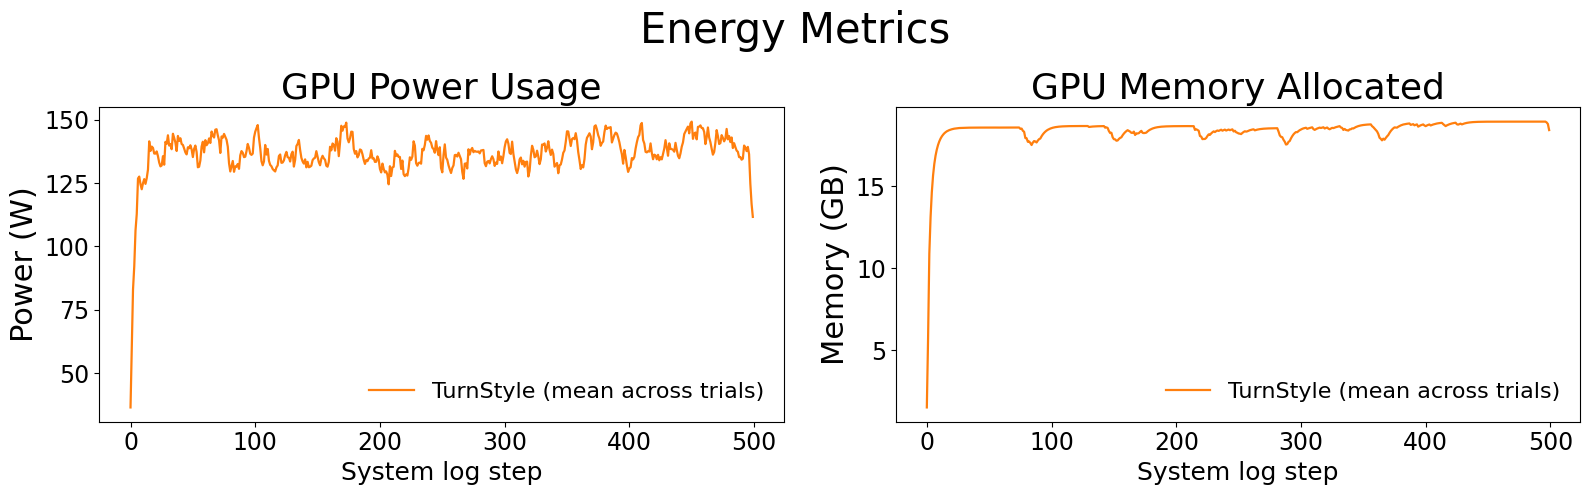

In [44]:

# --- colors ---
palette  = list(plt.cm.tab10.colors)
labels   = list(sys_data.keys())
colors   = {label: palette[i % 10] for i, label in enumerate(labels)}
colors["baseline"] = "red"

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Energy Metrics", fontsize=30)

for label, df in sys_data.items():
    if label == "baseline": continue
    lw = 2.2 if label == "baseline" else 1.6
    ls = "--" if label == "baseline" else "-"

    if power_col and power_col in df.columns:
        s = smooth(df[power_col])
        axes[0].plot(s.index, s.values, label=label, color=colors[label], lw=lw, ls=ls)

    if mem_col and mem_col in df.columns:
        s = smooth(df[mem_col])
        if s.max() > 1e6:
            s = s / 1e9
        axes[1].plot(s.index, s.values, label=label, color=colors[label], lw=lw, ls=ls)

axes[0].set_title("GPU Power Usage", fontsize=26)
axes[0].set_xlabel("System log step", fontsize=18)
axes[0].set_ylabel("Power (W)", fontsize=22)
axes[0].tick_params(labelsize=17)
axes[0].legend(fontsize=16, frameon=False)

axes[1].set_title("GPU Memory Allocated", fontsize=26)
axes[1].set_xlabel("System log step", fontsize=18)
axes[1].set_ylabel("Memory (GB)", fontsize=22)
axes[1].tick_params(labelsize=17)
axes[1].legend(fontsize=16, frameon=False)

plt.tight_layout()
# plt.savefig(FIGURE_OUTPUT + "/" + "system_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
